In [12]:
from utils.general_utils import set_seed
from dvrl.dataset import EssayDataset
import torch
import polars as pl
import numpy as np

target_prompt_id = 8
device = torch.device('cuda')
set_seed(12)

# Load essay data
print('Loading essay data...')
dataset = EssayDataset('../data/training_set_rel3.xlsx', '../data/hand_crafted_v3.csv', '../data/readability_features.csv')
dataset.preprocess_dataframe()
train_data, dev_data, test_data = dataset.cross_prompt_split(
    target_prompt_set=target_prompt_id,
    dev_size=30,
    cache_dir='.embedding_cache',
    embedding_model='microsoft/deberta-v3-large',
    add_pos=False,
    device=device,
    selection_method='euclidean',
)
print(f'    Number of training samples: {len(train_data["essay_id"])}')
print(f'    Number of dev samples: {len(dev_data["essay_id"])}')
print(f'    Number of test samples: {len(test_data["essay_id"])}')
print(f'    Selected Dev data: {dev_data["essay_id"]}')
print(f'    The score of selected Dev data: {dev_data["original_score"]}')

# load pseudo label
df = pl.read_csv('../data/pseudo_label_by_features_model.csv').to_dict()
pseudo_dict = dict(zip(df['essay_id'].to_numpy(), df['y_pred'].to_numpy()))

Loading essay data...


/home/ito/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
0it [00:00, ?it/s]
0it [00:00, ?it/s]


    Number of training samples: 12254
    Number of dev samples: 30
    Number of test samples: 693
    Selected Dev data: [20735 20871 20888 20915 20954 21010 21017 21020 21029 21103 21140 21150
 21179 21192 21200 21263 21301 21315 21318 21331 21365 21389 21408 21446
 21465 21476 21477 21521 21556 21619]
    The score of selected Dev data: [20 20 50 40 15 40 27 33 30 32 24 28 31 35 40 32 21 35 29 26 37 20 21 30
 36 28 28 38 44 10]


array([10, 15, 20, 21, 24, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38,
       40, 44, 50])

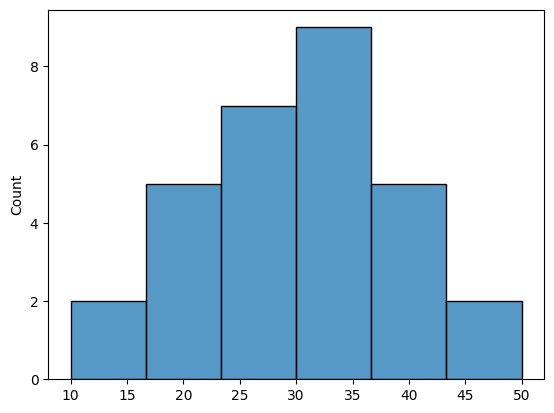

In [13]:
import seaborn as sns

sns.histplot(dev_data['original_score'])
np.unique(dev_data['original_score'])

array([20, 22, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 55, 60])

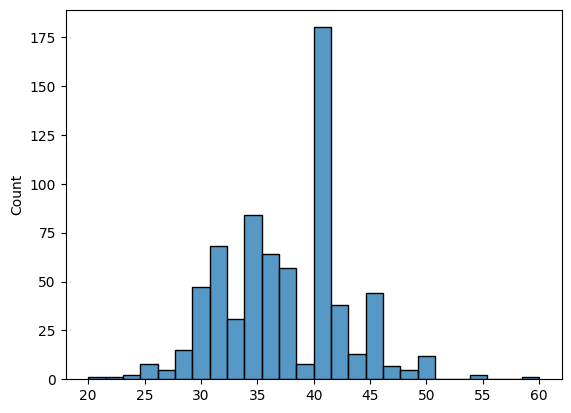

In [14]:
sns.histplot(test_data['original_score'])
np.unique(test_data['original_score'])

In [15]:
from sklearn.metrics import cohen_kappa_score
from utils.general_utils import get_min_max_scores
import numpy as np

y_pred_dev = dev_data['scaled_score'] + np.random.uniform(0.0, 0.3, len(dev_data['scaled_score']))
y_pred_test = test_data['scaled_score'] + np.random.uniform(0.0, 0.3, len(test_data['scaled_score']))

y_pred_dev = np.clip(y_pred_dev, 0, 1)
y_pred_test = np.clip(y_pred_test, 0, 1)

min_score, max_score = get_min_max_scores()[target_prompt_id]['score']

y_pred_dev = np.round((max_score - min_score) * y_pred_dev + min_score)
y_pred_test = np.round((max_score - min_score) * y_pred_test + min_score)

dev_qwk = cohen_kappa_score(dev_data['original_score'], y_pred_dev, weights='quadratic', labels=[i for i in range(min_score, max_score+1)])
test_qwk = cohen_kappa_score(test_data['original_score'], y_pred_test, weights='quadratic', labels=[i for i in range(min_score, max_score+1)])

print(dev_qwk)
print(test_qwk)

0.5674540682414698
0.3472586399098456
